In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
%config InlineBackend.figure_format = 'retina'

In [2]:
np.random.seed(42)
n = 1000
target_corr = 0.65

X = np.random.randn(n)

noise = np.random.randn(n)

Y = target_corr * X + np.sqrt(1 - target_corr ** 2) * noise

n_outliers = int(0.05 * n)
outlier_X = np.random.uniform(-4, 4, size=n_outliers)
outlier_Y = np.random.uniform(-4, 4, size=n_outliers)

X = np.concatenate([X, outlier_X])
Y = np.concatenate([Y, outlier_Y])

In [3]:
data = pd.DataFrame({'X': X, 'y': Y})

In [4]:
data

,X,y
0,0.496714,1.386282
1,-0.138264,0.612789
2,0.647689,0.466313
3,1.523030,0.498340
4,-0.234153,0.378404
...,...,...
1045,0.161359,1.153194
1046,-2.856992,-3.614512
1047,2.202769,-1.119596
1048,-1.828725,3.654399


<Axes: xlabel='X', ylabel='y'>

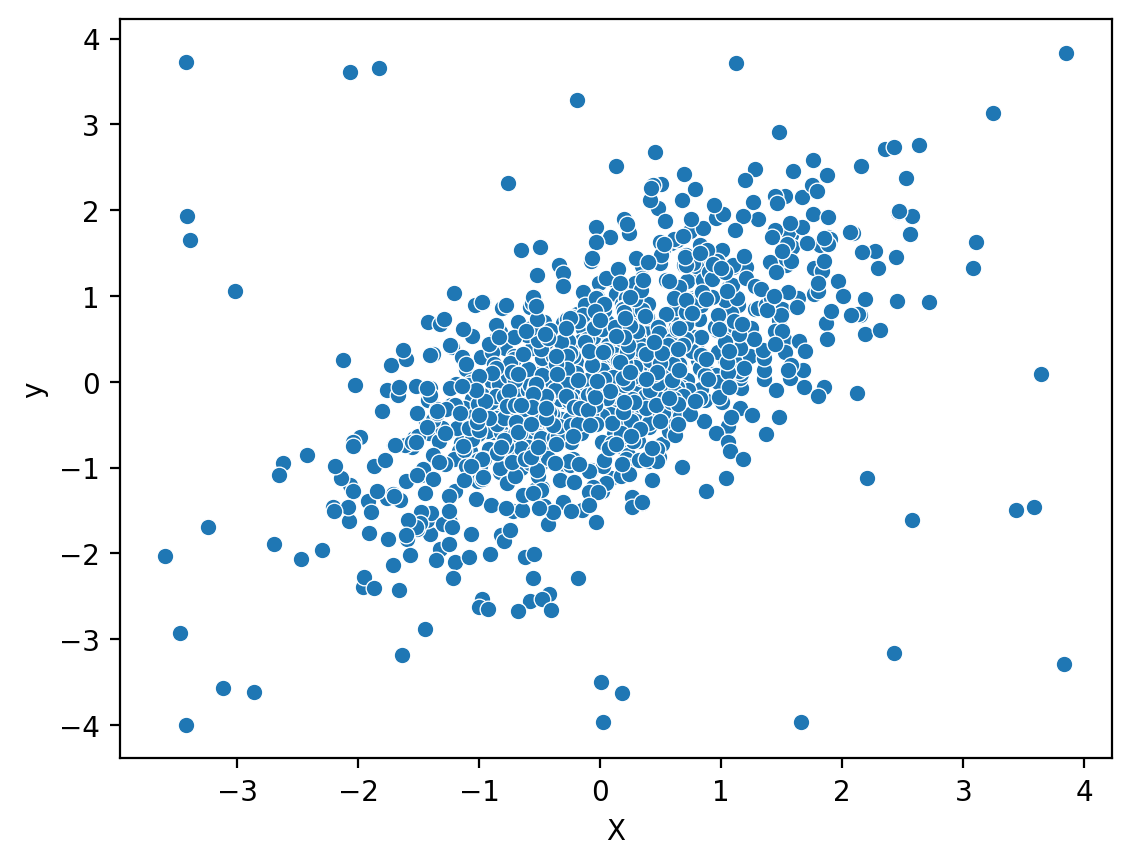

In [5]:
sns.scatterplot(x = 'X', y = 'y', data = data)

In [6]:
X = data['X']

In [7]:
y = data['y']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [9]:
X_ones = np.column_stack((np.ones(len(X)), np.array(X)))

In [10]:
w = np.linalg.inv(X_ones.T @ X_ones) @ (X_ones.T @ y)

In [11]:
w

array([0.04645367, 0.51494643])

In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [14]:
model.coef_, model.intercept_

(array([0.51668581]), np.float64(0.025336991836353275))

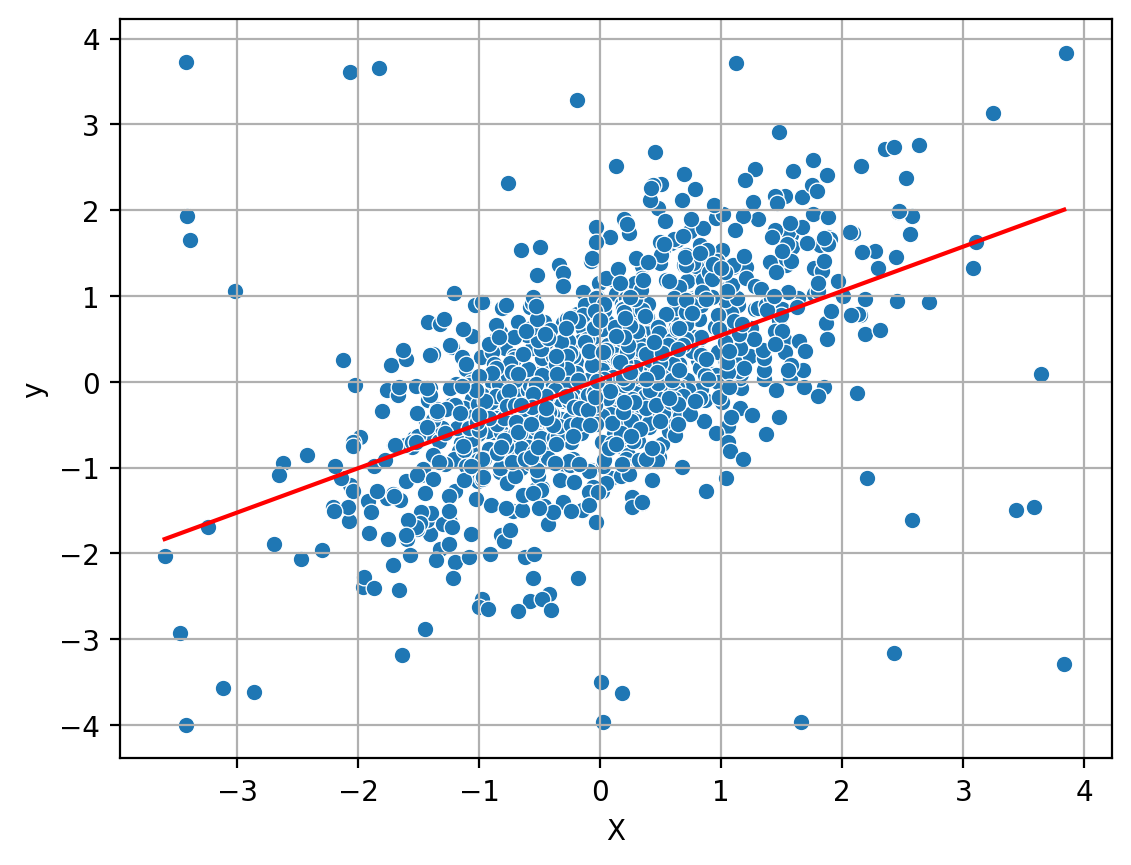

In [15]:
sns.scatterplot(x = 'X', y = 'y', data = data)
x_line = np.linspace(data['X'].min(), data['y'].max(), 100)
y_line = model.intercept_ + model.coef_ * x_line
plt.plot(x_line, y_line, color = 'red')
plt.grid(1)
plt.show()

In [16]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [17]:
def metrics(y_test, model_pred):
    MAPE = mean_absolute_percentage_error(y_test, model_pred)
    MAE = mean_absolute_error(y_test, model_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, model_pred))
    
    print(f"Mean Absolute Persentage Error: {MAPE:.5f}%")
    print(f"Mean Absolute Error: {MAE:.5f}")
    print(f"Root Mean Squared Error: {RMSE:.5f}")

In [18]:
metrics(y_test, y_pred)

Mean Absolute Persentage Error: 3.45176%
Mean Absolute Error: 0.71101
Root Mean Squared Error: 0.97376


In [19]:
ridge_model = RidgeCV(alphas = (0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100), cv = 5)

In [20]:
ridge_model.fit(X_train.values.reshape(-1, 1), y_train)

RidgeCV(alphas=(1e-05, 0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100),
        cv=5)

In [21]:
ridge_model.alpha_

np.float64(5.0)

In [22]:
ridge_model.coef_, ridge_model.intercept_

(array([0.51404464]), np.float64(0.025306895765692363))

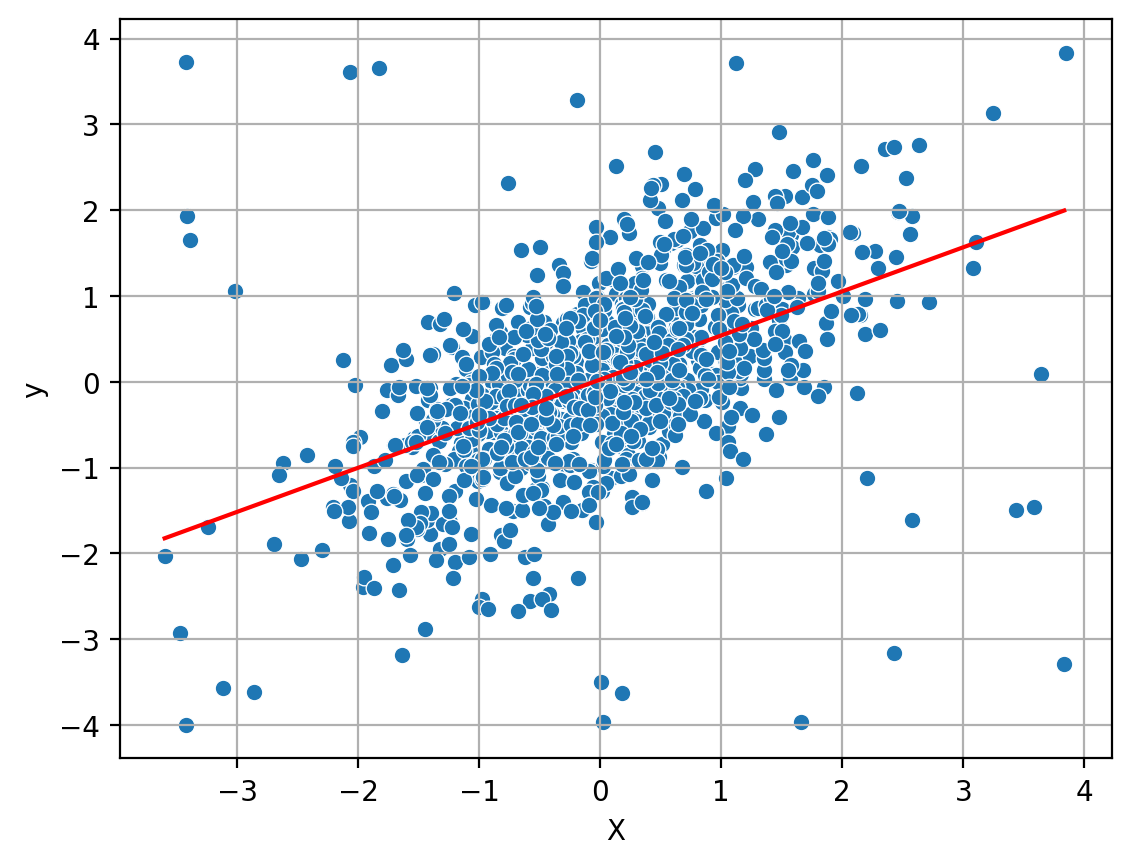

In [23]:
sns.scatterplot(x = 'X', y = 'y', data = data)
x_line = np.linspace(data['X'].min(), data['y'].max(), 100)
y_line = ridge_model.intercept_ + ridge_model.coef_ * x_line
plt.plot(x_line, y_line, color = 'red')
plt.grid(1)
plt.show()

In [24]:
ridge_pred = ridge_model.predict(X_test.values.reshape(-1, 1))

In [25]:
metrics(y_test, ridge_pred)

Mean Absolute Persentage Error: 3.43677%
Mean Absolute Error: 0.71114
Root Mean Squared Error: 0.97374


In [26]:
metrics(y_test, y_pred)

Mean Absolute Persentage Error: 3.45176%
Mean Absolute Error: 0.71101
Root Mean Squared Error: 0.97376


In [27]:
lasso_model = LassoCV(eps = 0.001, alphas = (0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100), cv = 5)

In [28]:
lasso_model.fit(X_train.values.reshape(-1, 1), y_train)

LassoCV(alphas=(1e-05, 0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 20, 50, 100),
        cv=5)

In [29]:
lasso_model.alpha_

np.float64(1e-05)

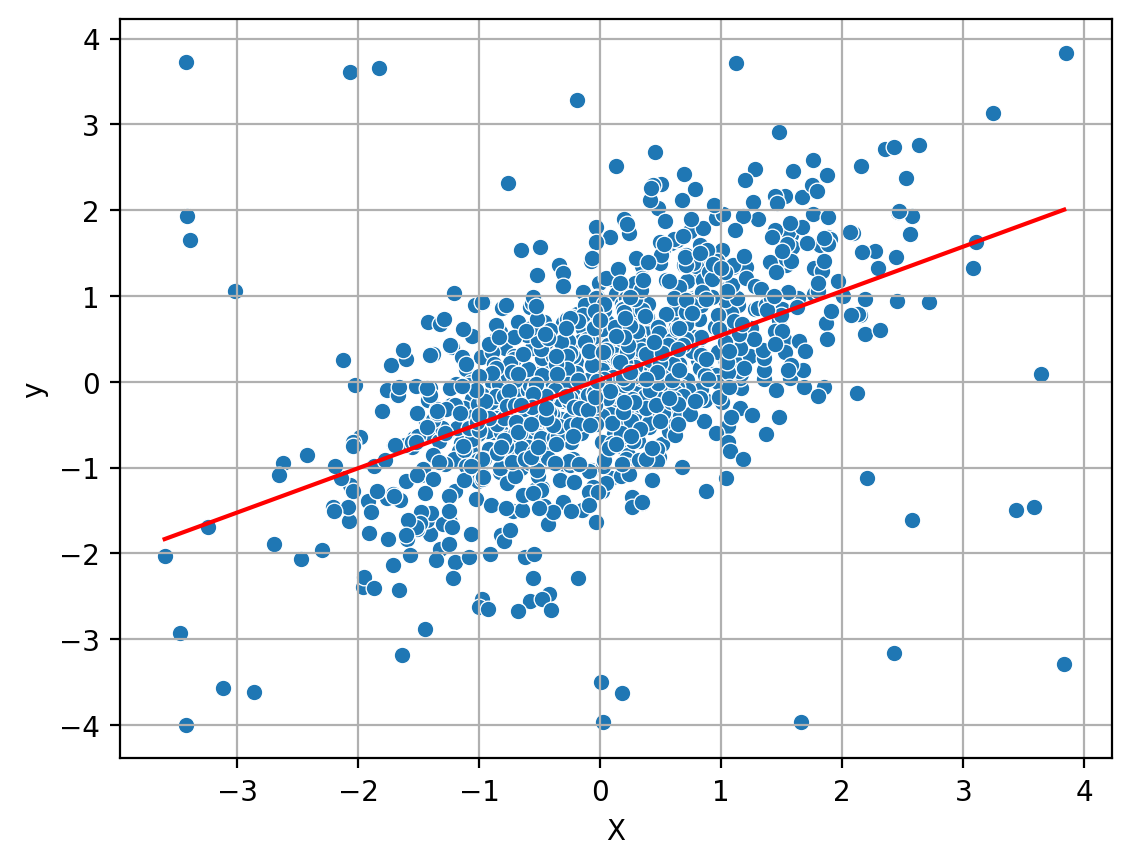

In [30]:
sns.scatterplot(x = 'X', y = 'y', data = data)
x_line = np.linspace(data['X'].min(), data['y'].max(), 100)
y_line = lasso_model.intercept_ + lasso_model.coef_ * x_line
plt.plot(x_line, y_line, color = 'red')
plt.grid(1)
plt.show()

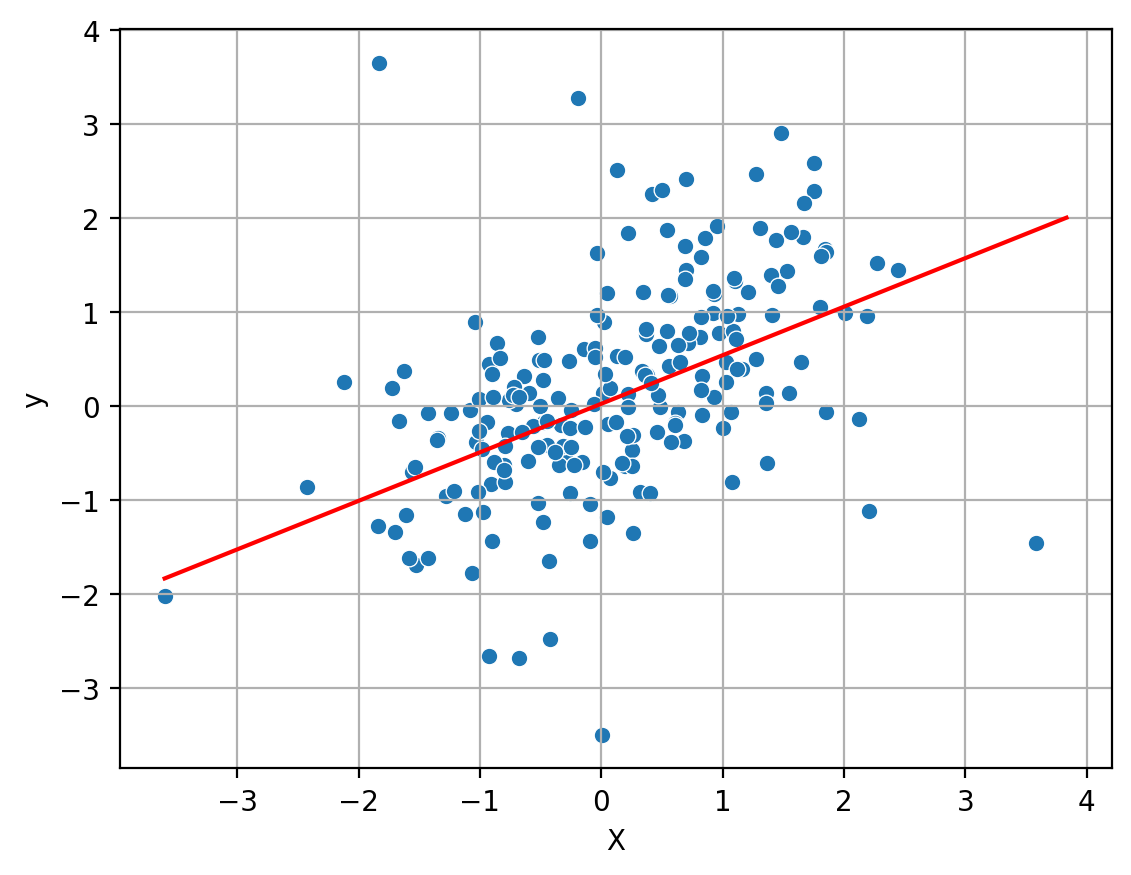

In [31]:
sns.scatterplot(x = X_test, y = y_test)
x_line = np.linspace(data['X'].min(), data['y'].max(), 100)
y_line = lasso_model.intercept_ + lasso_model.coef_ * x_line
plt.plot(x_line, y_line, color = 'red')
plt.grid(1)
plt.show()

In [32]:
lasso_pred = lasso_model.predict(X_test.values.reshape(-1, 1))

In [33]:
metrics(y_test, lasso_pred)

Mean Absolute Persentage Error: 3.45171%
Mean Absolute Error: 0.71101
Root Mean Squared Error: 0.97376


In [34]:
elastic_model = ElasticNetCV(l1_ratio = [0.001, 0.01, 0.1, 0.2, 0.5, 0.75, 0.9, 1],
                            eps = 0.001, n_alphas = 100)

In [35]:
elastic_model.fit(X_train.values.reshape(-1, 1), y_train)

ElasticNetCV(l1_ratio=[0.001, 0.01, 0.1, 0.2, 0.5, 0.75, 0.9, 1])

In [36]:
elastic_model.l1_ratio_

np.float64(0.1)

In [37]:
elastic_model.alpha_

np.float64(0.00598579116238278)

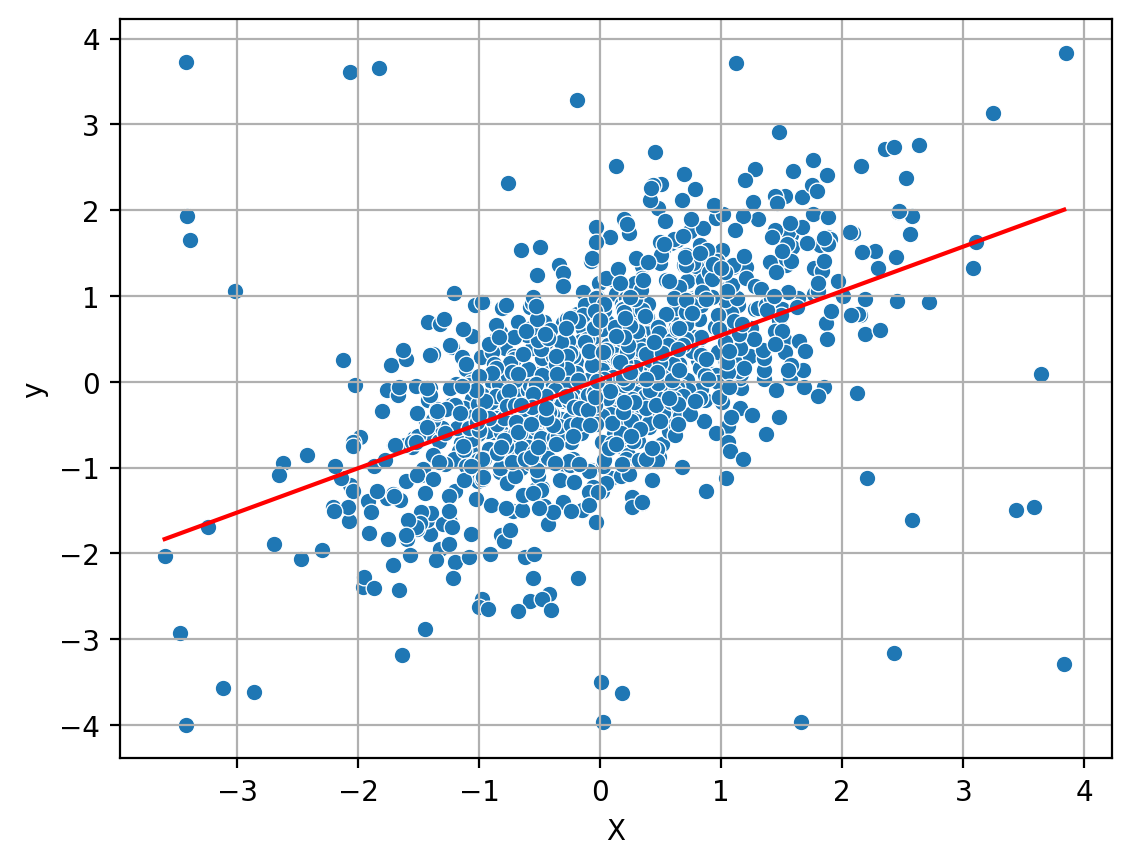

In [38]:
sns.scatterplot(x = 'X', y = 'y', data = data)
x_line = np.linspace(data['X'].min(), data['y'].max(), 100)
y_line = lasso_model.intercept_ + lasso_model.coef_ * x_line
plt.plot(x_line, y_line, color = 'red')
plt.grid(1)
plt.show()

In [39]:
elastic_pred = elastic_model.predict(X_test.values.reshape(-1, 1))

In [40]:
metrics(y_test, elastic_pred)

Mean Absolute Persentage Error: 3.43527%
Mean Absolute Error: 0.71115
Root Mean Squared Error: 0.97374
